# Multi Layer Perceptron (MLP) Algorithm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(42)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
torch.manual_seed(42)


class MLP(nn.Module):
    def __init__(self, layers, activation='relu', dropout=0.0):
        super().__init__()

        if len(layers) < 2:
            raise ValueError("The 'layers' list must have at least 2 elements (input and output).")

        self.layers = nn.ModuleList()

        activation_functions = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh()
        }

        if activation not in activation_functions:
            raise ValueError("Use 'relu' or 'tanh'.")

        self.activation = activation_functions[activation]

        self.dropouts = nn.ModuleList()

        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i + 1]))

            if i < len(layers) - 2:
                self.dropouts.append(nn.Dropout(dropout))

    def forward(self, x):

        for i in range(len(self.layers) - 1):
            x = self.layers[i](x)
            x = self.activation(x)
            x = self.dropouts[i](x)

        x = self.layers[-1](x)

        return x


def get_loss(num_classes):

    if num_classes == 2:
        return nn.BCEWithLogitsLoss()
    else:
        return nn.CrossEntropyLoss()


def get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0):

    if optimizer_name == 'sgd':
        return optim.SGD(model.parameters(), lr=lr, weight_decay=l2_lambda)
    else:
        return optim.Adam(model.parameters(), lr=lr, weight_decay=l2_lambda)


def compute_accuracy(outputs, y, num_classes):

    if num_classes == 2:
        preds = (torch.sigmoid(outputs) > 0.5).float()
    else:
        preds = torch.argmax(outputs, dim=1)

    return (preds == y).float().mean().item()


def train(model, X_train, y_train, X_val, y_val,
          epochs, optimizer, criterion,
          num_classes, patience=20):    

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        outputs = model(X_train)

        loss = criterion(outputs, y_train)

        loss.backward()
        
        optimizer.step()

        model.eval()

        with torch.no_grad():

            train_outputs = model(X_train)
            train_loss = criterion(train_outputs, y_train)

            train_acc = compute_accuracy(
                train_outputs,
                y_train,
                num_classes
            )

            val_outputs = model(X_val)
            val_loss = criterion(val_outputs, y_val)

            val_acc = compute_accuracy(
                val_outputs,
                y_val,
                num_classes
            )

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        train_accs.append(train_acc)
        val_accs.append(val_acc)

        improved = False

        if val_loss.item() < best_val_loss - 1e-4:
            improved = True

        elif abs(val_loss.item() - best_val_loss) <= 1e-4:
            if len(val_accs) == 1 or val_acc >= max(val_accs[:-1]):
                improved = True

        if improved:

            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0

        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_losses, val_losses, train_accs, val_accs


def evaluate(model, X, y, num_classes):

    model.eval()

    with torch.no_grad():

        outputs = model(X)
        acc = compute_accuracy(outputs, y, num_classes)

    return acc

In [4]:
def plot_decision_boundary_line(model, X, y):

    model.eval()

    # Tensor to numpy
    if torch.is_tensor(X):
        X = X.detach().cpu().numpy()
    if torch.is_tensor(y):
        y = y.detach().cpu().numpy()

    y = y.squeeze()

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid, dtype=torch.float32)

    with torch.no_grad():
        outputs = model(grid_tensor)
        Z = torch.sigmoid(outputs).squeeze().reshape(xx.shape).numpy()

    plt.contour(xx, yy, Z, levels=[0.5], colors='black')

    classes = np.unique(y)

    for c in classes:
        idx = (y == c)
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            label=f"Class {int(c)}",
            edgecolors='k'
        )

    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.legend()

    plt.show()

## Dataset 1

* 2 features, 140 train samples and 60 test samples;

### Train and validation

In [5]:
df_train1 = pd.read_csv('train_dataset1.csv')

X_train1 = df_train1.drop('label', axis=1).values
y_train1 = df_train1['label'].values

le = LabelEncoder()
y_train1 = le.fit_transform(y_train1)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train1,
    y_train1,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_train1
)

scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_tr = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

num_classes = len(le.classes_)

#### Experiment 1 - Base Model

In [1167]:
layers = [2, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

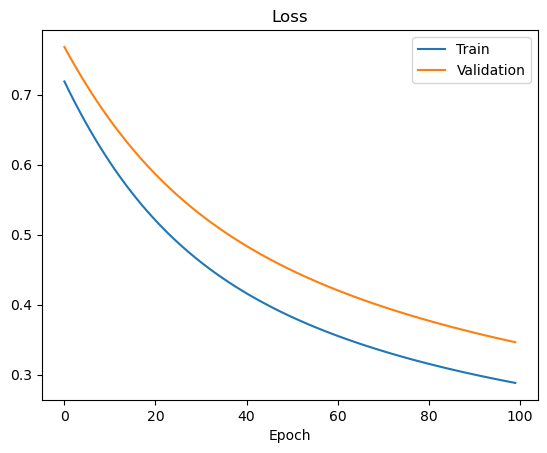

In [1168]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9553571343421936
Validation accuracy final: 0.9642857313156128


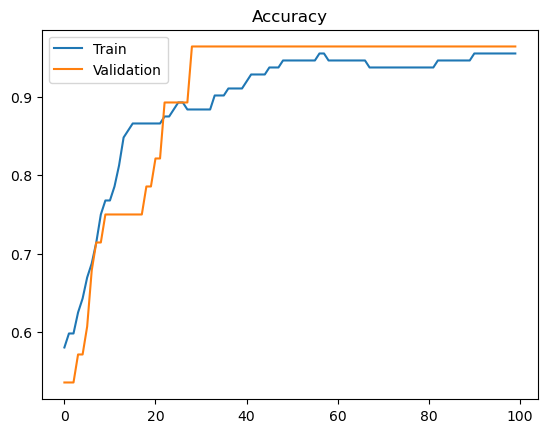

In [1169]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

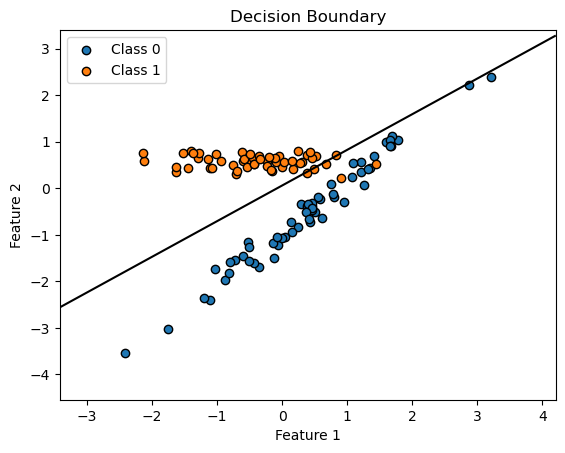

In [1170]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 2 - One hidden Layer

In [1171]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

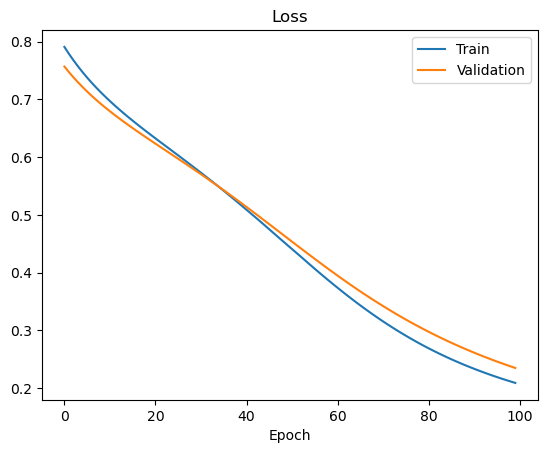

In [1172]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9732142686843872
Validation accuracy final: 1.0


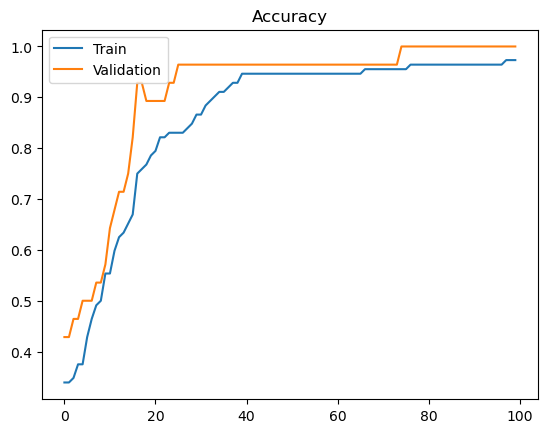

In [1173]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

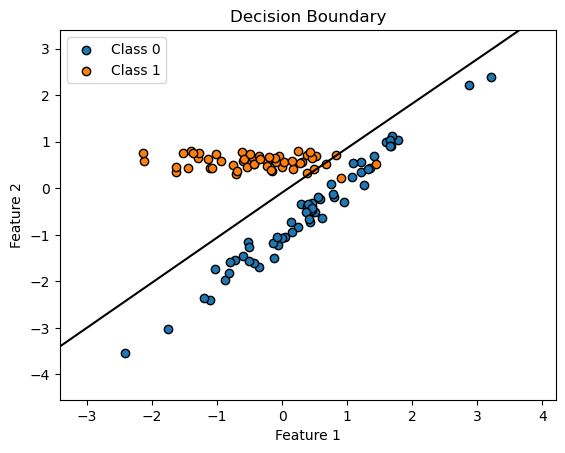

In [1174]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 3 - More neurons in the hidden layer

In [1175]:
layers = [2, 8, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

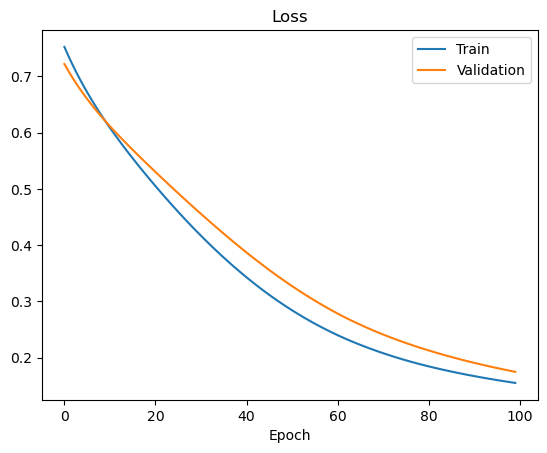

In [1176]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9821428656578064
Validation accuracy final: 1.0


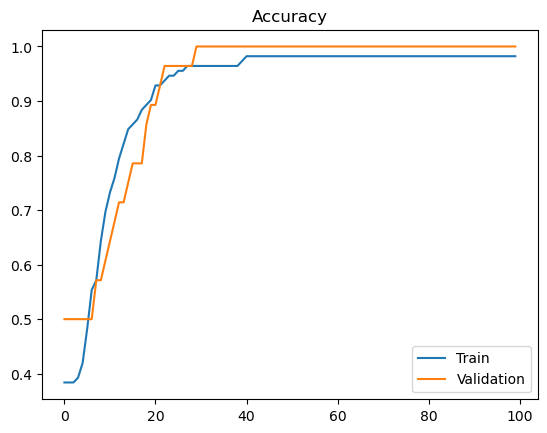

In [1177]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

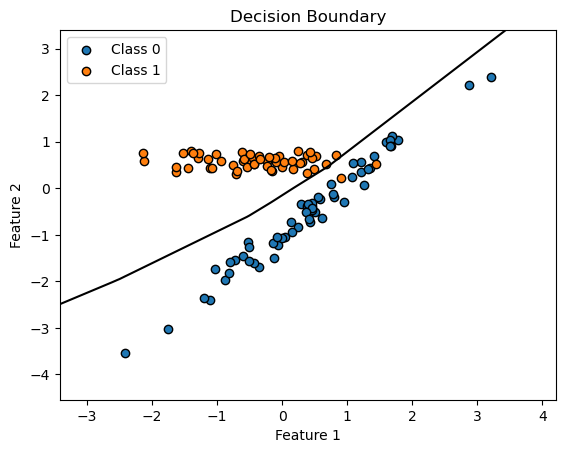

In [1178]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 4 - Deep neural network

In [1179]:
layers = [2, 4, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

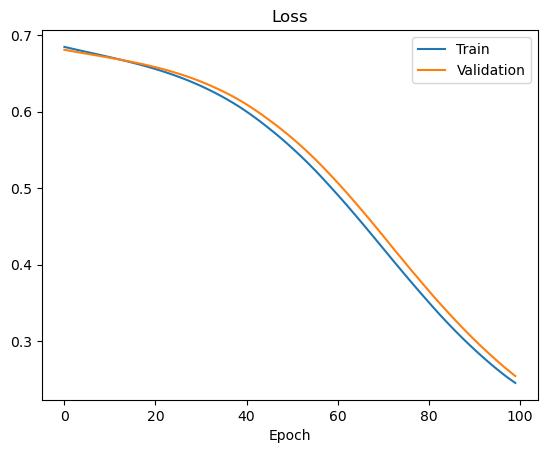

In [1180]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9821428656578064
Validation accuracy final: 1.0


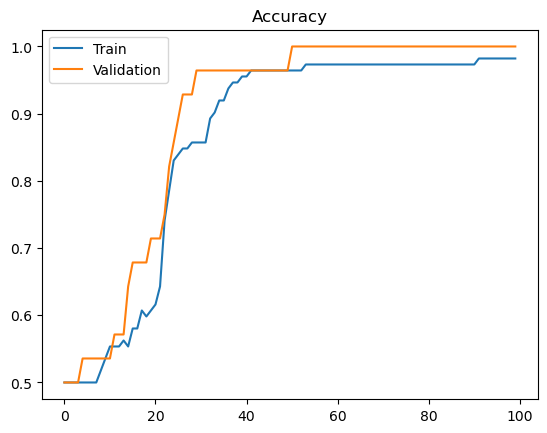

In [1181]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

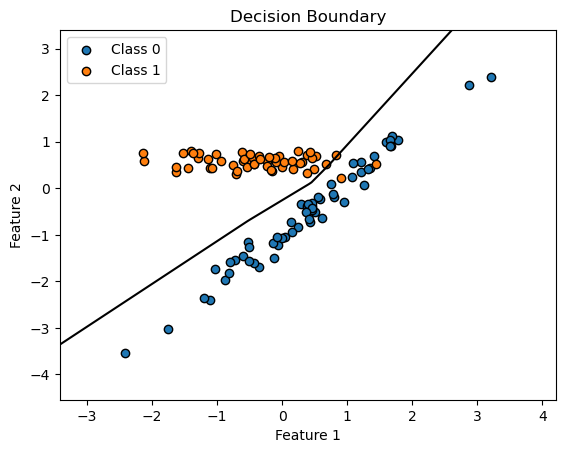

In [1182]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 5 - with droupout

In [1183]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

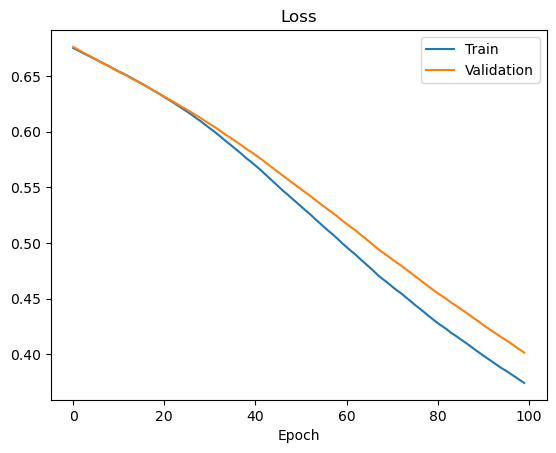

In [1184]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9464285969734192
Validation accuracy final: 0.9642857313156128


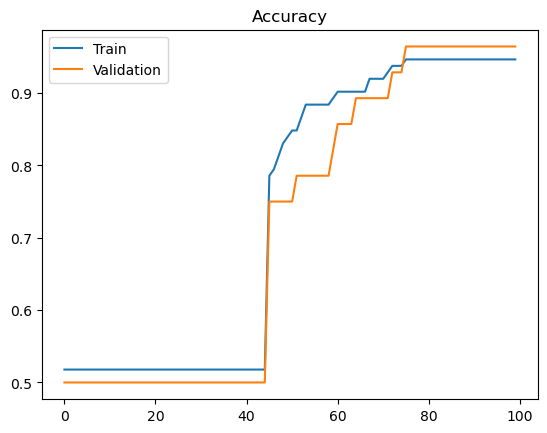

In [1185]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

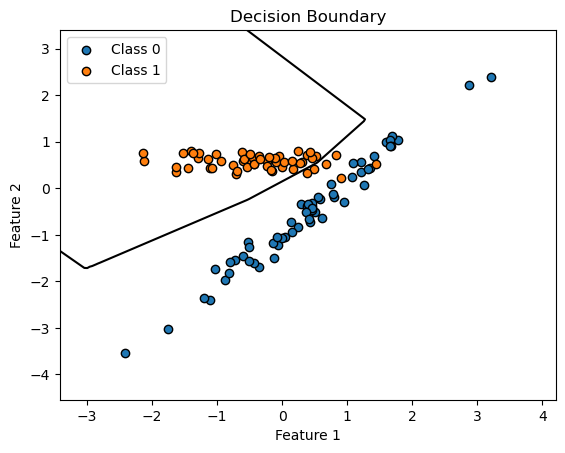

In [1186]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 6 - with L2 regularization

In [1187]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

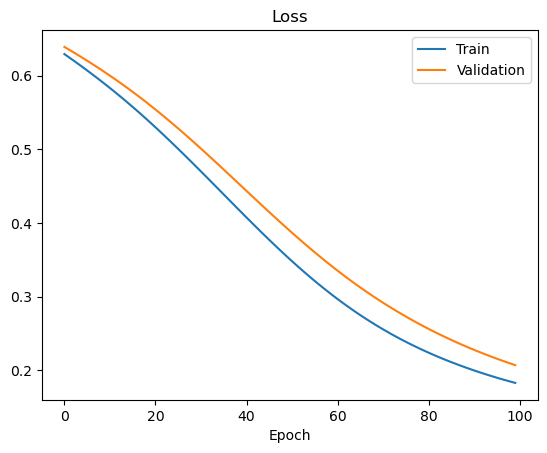

In [1188]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9732142686843872
Validation accuracy final: 1.0


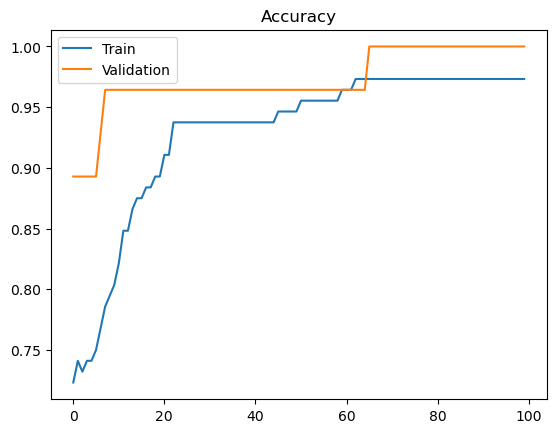

In [1189]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

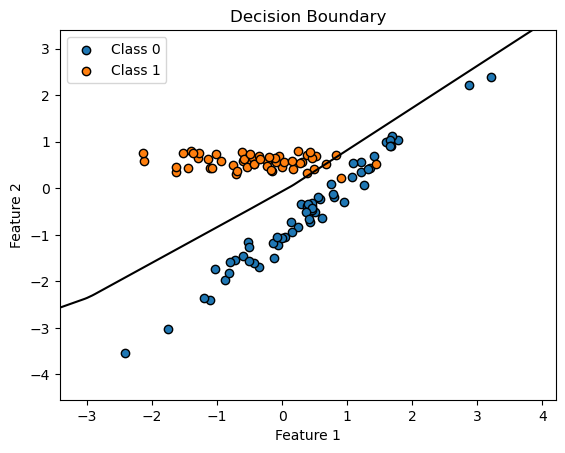

In [1190]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 7 - Adam optimization

In [1191]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

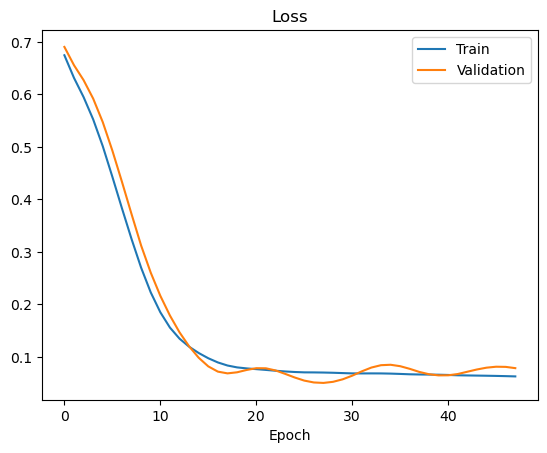

In [1192]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9821428656578064
Validation accuracy final: 0.9642857313156128


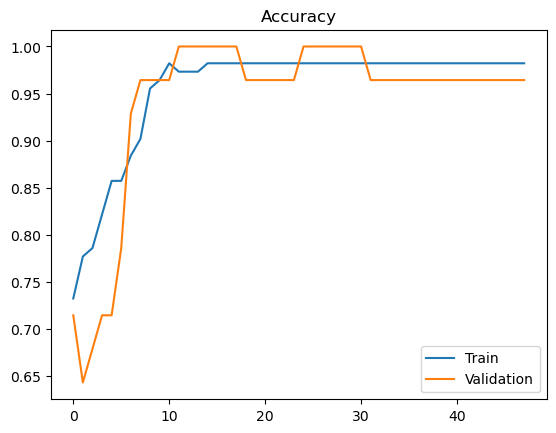

In [1193]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

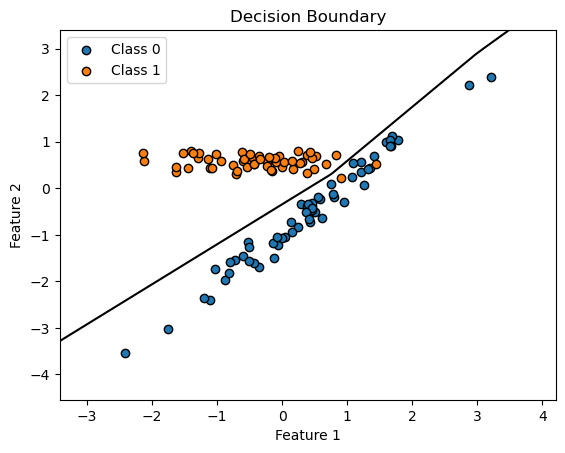

In [1194]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 8 - Tanh activation function

In [1195]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='tanh', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

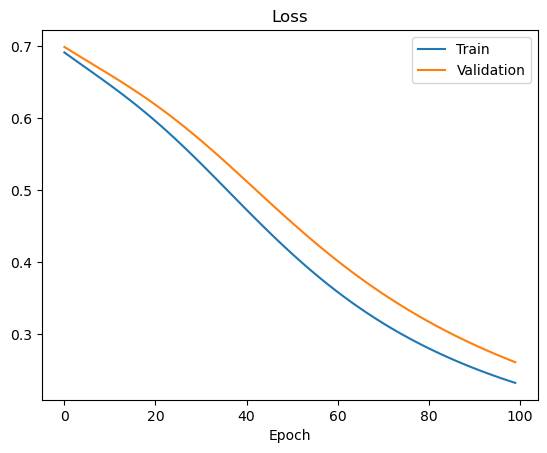

In [1196]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9821428656578064
Validation accuracy final: 1.0


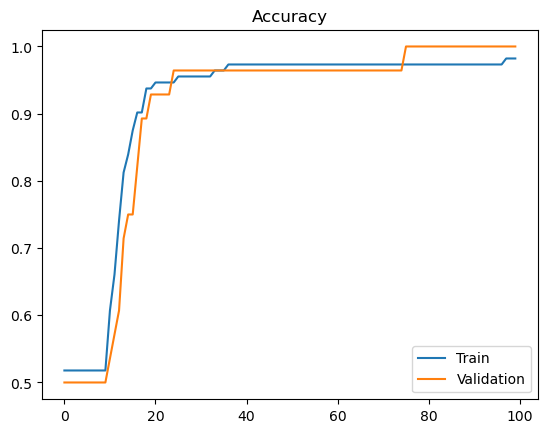

In [1197]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

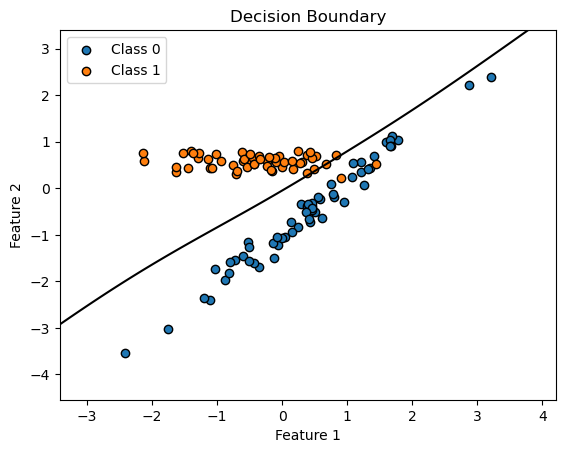

In [1198]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

# Conclusions about Dataset 1

## General Characteristics

Dataset 1 contains only 2 input features and a binary classification problem, suggesting a relatively simple decision boundary. Therefore, this dataset is expected to be solved using smaller architectures and simpler optimization strategies.

---

## 1. Experiment 1 as Base Model

Experiment 1 serves as a benchmark model, using a simple architecture with SGD and no regularization.

The obtained metrics were already very strong:

- Train Accuracy ≈ 95.54%
- Validation Accuracy = 96.43%

This indicates that the dataset is highly learnable and likely close to linearly separable. The small gap between training and validation accuracy suggests good generalization, with no clear evidence of overfitting.

---

## 2. Increasing Architecture Complexity

Further experiments using deeper or larger networks slightly improved training accuracy, in some cases reaching:

- Train Accuracy ≈ 98.21%
- Validation Accuracy = 100%

This demonstrates that increasing model complexity improved the fitting of the training data. However, the gain in validation performance was negligible, since simpler models had already reached perfect validation accuracy.

Therefore, increasing depth or width did not provide meaningful practical gains for this dataset.

---

## 3. Effect of Regularization

Dropout and L2 regularization did not significantly improve the results.

Since the dataset is simple and already generalizes well, regularization was not necessary. In some cases, regularization may slightly reduce training performance by making optimization harder.

This behavior is expected when the original model is already sufficiently simple.

---

## 4. Optimizer Comparison

SGD already performed extremely well on this dataset. However, Adam performed very well, reaching similarly results in a few epochs.

This suggests that Dataset 1 does not require advanced optimization methods due to its low complexity.

---

## Final Conclusion for Dataset 1

Dataset 1 is a relatively simple binary classification problem. Even shallow models with SGD were sufficient to obtain excellent performance. Increasing complexity or adding regularization did not significantly improve validation accuracy.

The best practical conclusion is that simpler models are preferable, since they achieve high accuracy with lower computational cost and lower risk of unnecessary complexity.

### Test

In [1199]:
df_test1 = pd.read_csv('test_dataset1.csv')

X_test1 = df_test1.drop('label', axis=1).values
y_test1 = df_test1['label'].values

X_test1 = scaler.transform(X_test1)

X_test1 = torch.tensor(X_test1, dtype=torch.float32)

y_test1 = le.transform(y_test1)
y_test1 = torch.tensor(y_test1, dtype=torch.float32).unsqueeze(1)

num_classes = len(le.classes_)

In [1200]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='tanh', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.01, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
)

In [1201]:
print("Test accuracy:", evaluate(model, X_test1, y_test1, num_classes))

Test accuracy: 0.949999988079071


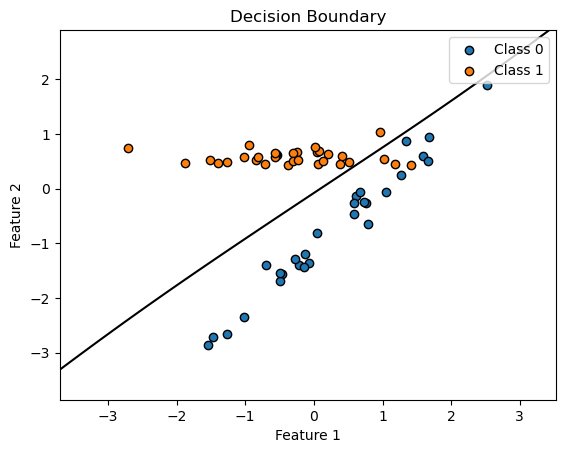

In [1202]:
plot_decision_boundary_line(
    model,
    X_test1.numpy(),
    y_test1.numpy().ravel()
)

---

## Dataset 2

* 2 features, 175 train samples and 75 test samples;

### Train and validation

In [1203]:
df_train2 = pd.read_csv('train_dataset2.csv')

X_train2 = df_train2.drop('label', axis=1).values
y_train2 = df_train2['label'].values

le = LabelEncoder()
y_train2 = le.fit_transform(y_train2)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train2,
    y_train2,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y_train2
)

scaler = StandardScaler()

X_tr = scaler.fit_transform(X_tr)
X_val = scaler.transform(X_val)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_tr = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

num_classes = len(le.classes_)

#### Experiment 1 - Inicial Setup

In [1204]:
layers = [2, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

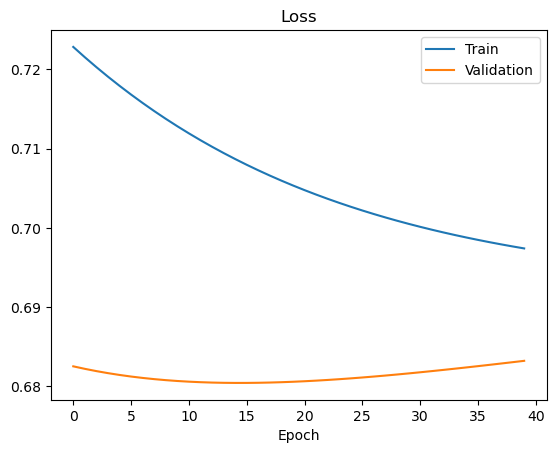

In [1205]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.6214285492897034
Validation accuracy final: 0.6857143044471741


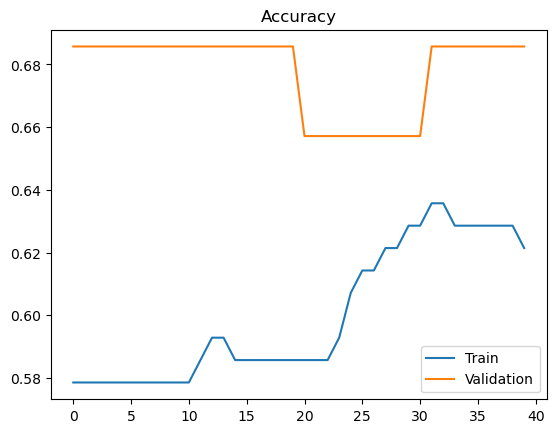

In [1206]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

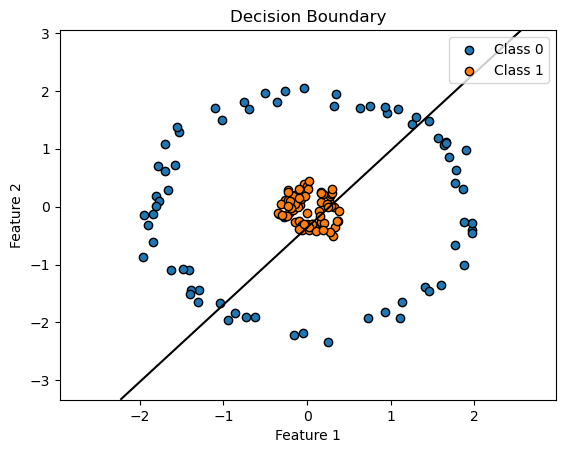

In [1207]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 2 - One hidden layer

In [1208]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

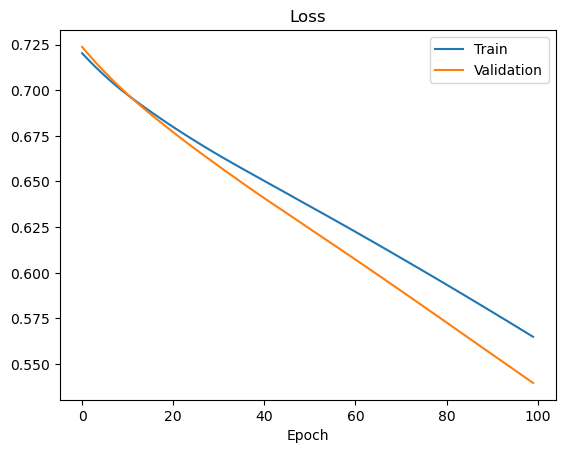

In [1209]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.7642857432365417
Validation accuracy final: 0.8285714387893677


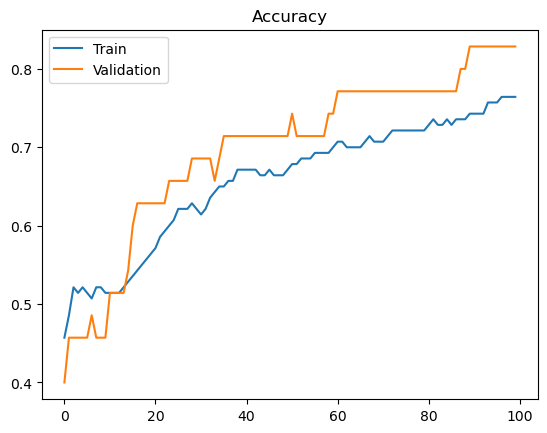

In [1210]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

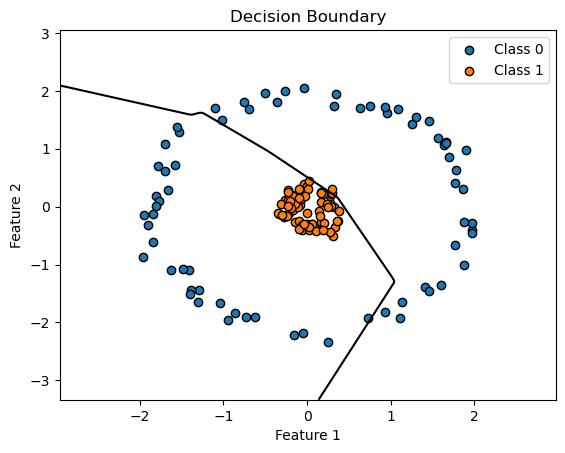

In [1211]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 3 - One hidder layer with Adam

In [1212]:
layers = [2, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

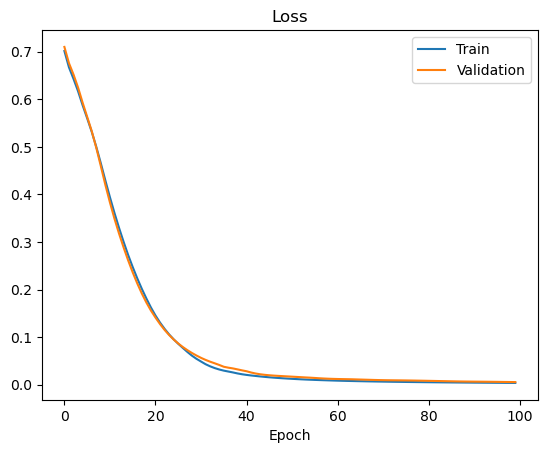

In [1213]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 1.0
Validation accuracy final: 1.0


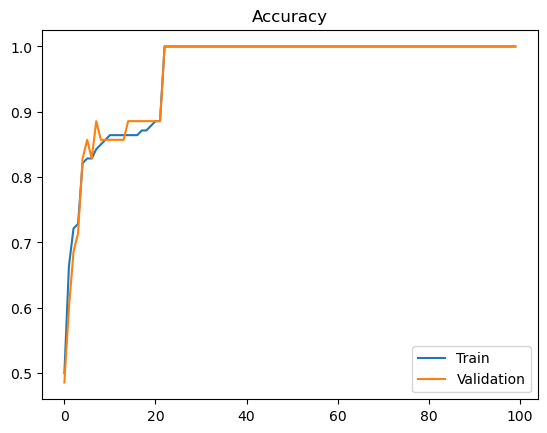

In [1214]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

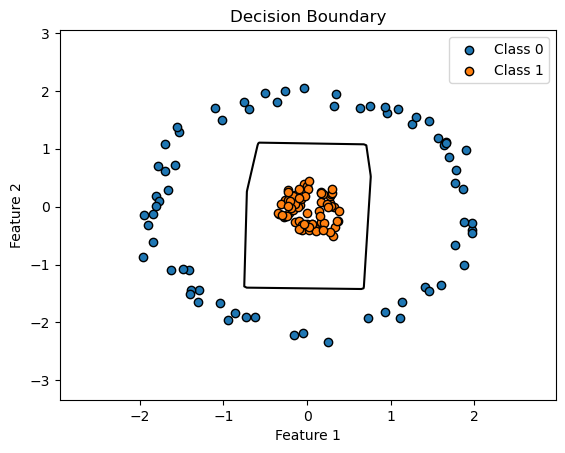

In [1215]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 4 - Two hidden layers with Adam and dropout

In [1216]:
layers = [2, 4, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

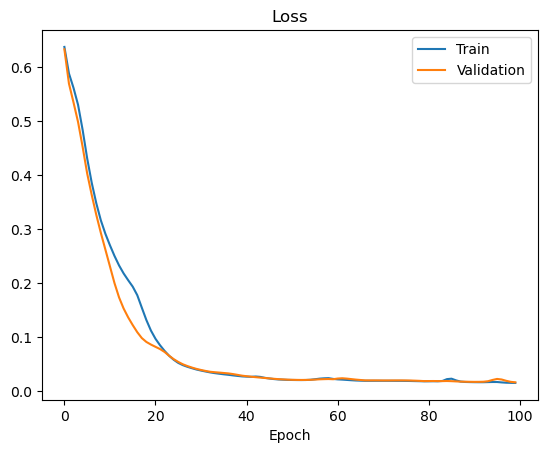

In [1217]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 1.0
Validation accuracy final: 1.0


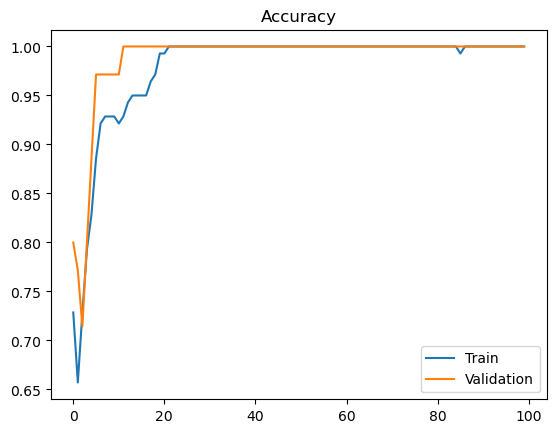

In [1218]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

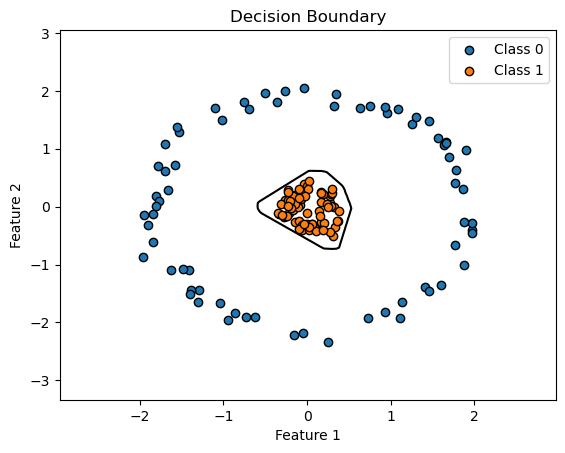

In [1219]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 5 - Two hidden layers with Adam, dropout and L2 regularization

In [1220]:
layers = [2, 4, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.1, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

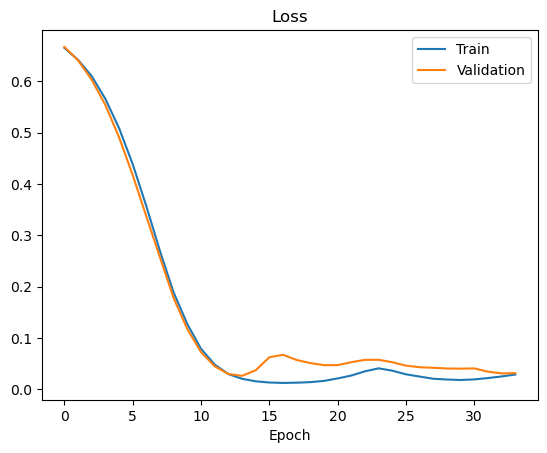

In [1221]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 1.0
Validation accuracy final: 1.0


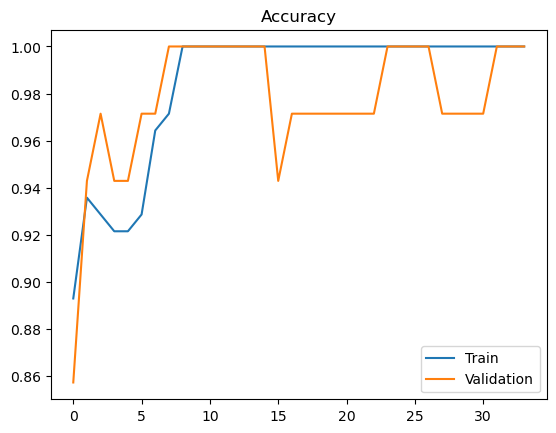

In [1222]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

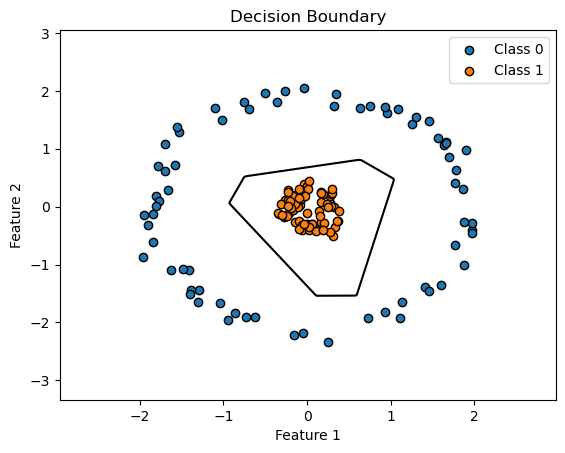

In [1223]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

#### Experiment 6 - Two hidden layers with Adam, dropout and small learning rate

In [1224]:
layers = [2, 4, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

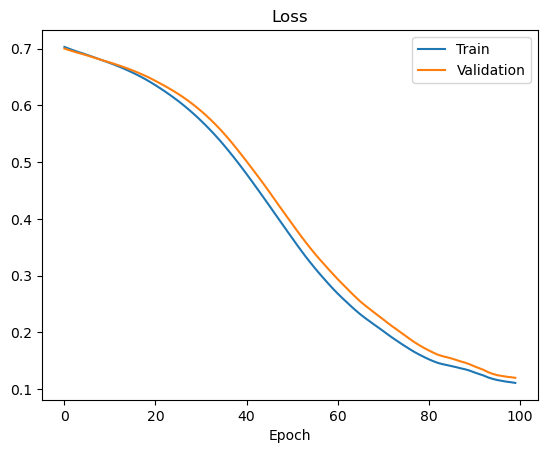

In [1225]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 1.0
Validation accuracy final: 1.0


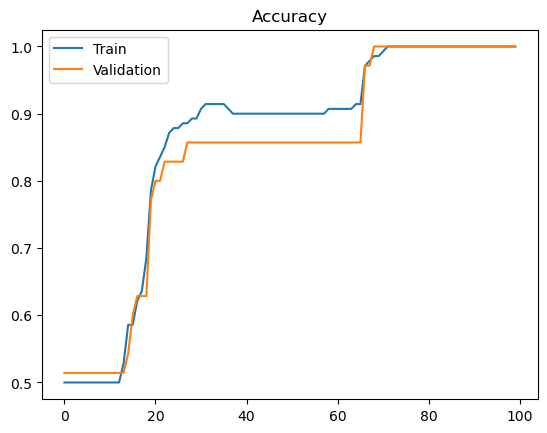

In [1226]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

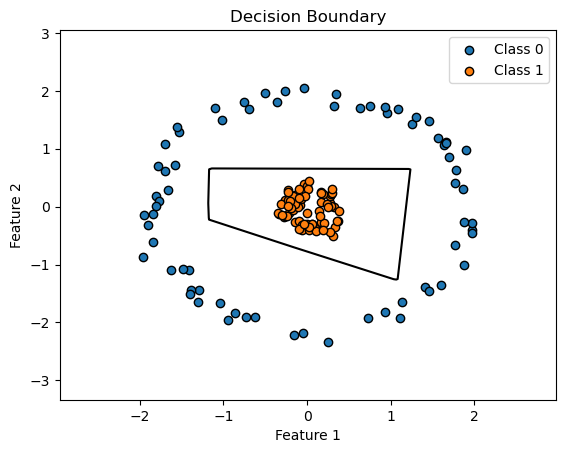

In [1227]:
plot_decision_boundary_line(
    model,
    X_tr.numpy(),
    y_tr.numpy().ravel()
)

# Conclusions about Dataset 2

## General Characteristics

Dataset 2 also contains 2 input features and a binary classification problem, but unlike Dataset 1, it appears to be non-linearly separable, requiring hidden layers and nonlinear activation functions.

---

## 1. Experiment 1 as Linear Baseline

The first experiment behaves as a linear model and obtained poor results:

- Train Accuracy ≈ 62.14%
- Validation Accuracy ≈ 68.57%

This indicates that a linear decision boundary is insufficient to separate the classes. Additionally, the poor loss minimization confirms that the model cannot adequately represent the dataset structure.

---

## 2. Adding Hidden Layers and Nonlinearity

Once hidden layers and nonlinear activation functions were introduced, performance increased drastically.

Examples:

### Experiment 2

- Train Accuracy ≈ 76.43%
- Validation Accuracy ≈ 82.86%

### Experiment 3

- Train Accuracy = 100%
- Validation Accuracy = 100%

This demonstrates that Dataset 2 requires nonlinear decision boundaries, and MLP architectures are highly effective in capturing them.

---

## 3. Effect of Complexity

Unlike Dataset 1, increasing architecture complexity was beneficial in Dataset 2.

Several models reached perfect validation accuracy, indicating that the additional representational capacity was necessary and useful.

However, once perfect accuracy is achieved, additional complexity becomes unnecessary.

---

## 4. Regularization and Optimizer Effects

Regularization did not appear critical, since several models generalized perfectly without it.

Adam likely accelerated convergence, but because the dataset became easy after introducing hidden layers, optimizer differences were less relevant than architecture choice.

---

## Final Conclusion for Dataset 2

Dataset 2 is a nonlinear binary classification problem. Linear models fail, but MLP architectures with hidden layers solve the task almost perfectly.

The main insight is that nonlinearity was far more important than increasing depth or adding regularization.

#### Test

In [1228]:
df_test2 = pd.read_csv('test_dataset2.csv')

X_test2 = df_test2.drop('label', axis=1).values
y_test2 = df_test2['label'].values

X_test2 = scaler.transform(X_test2)

X_test2 = torch.tensor(X_test2, dtype=torch.float32)

y_test2 = le.transform(y_test2)
y_test2 = torch.tensor(y_test2, dtype=torch.float32).unsqueeze(1)

num_classes = len(le.classes_)

In [1229]:
layers = [2, 8, 4, 1]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.1, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_tr,
    y_train=y_tr,
    X_val=X_val,
    y_val=y_val,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

In [1230]:
print("Test accuracy:", evaluate(model, X_test2, y_test2, num_classes))

Test accuracy: 0.9866666793823242


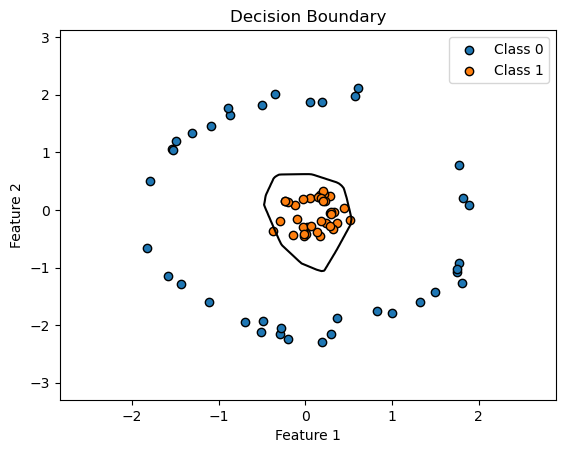

In [1231]:
plot_decision_boundary_line(
    model,
    X_test2.numpy(),
    y_test2.numpy().ravel()
)

---

## Dataset 3

* 768 train samples, 192 validation samples and 240 test samples with 50 features and 4 classes.

In [1232]:
df_train3 = pd.read_csv('train_dataset.csv')
df_val3   = pd.read_csv('validation_dataset.csv')
df_test3  = pd.read_csv('test_dataset.csv')

X_train3 = df_train3.drop('label', axis=1).values
X_val3   = df_val3.drop('label', axis=1).values
X_test3  = df_test3.drop('label', axis=1).values

y_train3 = df_train3['label'].values
y_val3   = df_val3['label'].values
y_test3  = df_test3['label'].values

le = LabelEncoder()

y_train3 = le.fit_transform(y_train3)
y_val3   = le.transform(y_val3)
y_test3  = le.transform(y_test3)

num_classes = len(le.classes_)

scaler = StandardScaler()

X_train3 = scaler.fit_transform(X_train3)
X_val3   = scaler.transform(X_val3)
X_test3  = scaler.transform(X_test3)

X_train3 = torch.tensor(X_train3, dtype=torch.float32)
X_val3   = torch.tensor(X_val3, dtype=torch.float32)
X_test3  = torch.tensor(X_test3, dtype=torch.float32)

y_train3 = torch.tensor(y_train3, dtype=torch.long)
y_val3   = torch.tensor(y_val3, dtype=torch.long)
y_test3  = torch.tensor(y_test3, dtype=torch.long)

### Experiment 1 

1) Small Architecture = [50, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0
5) L2 regularization = 0

In [1233]:
layers = [50, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

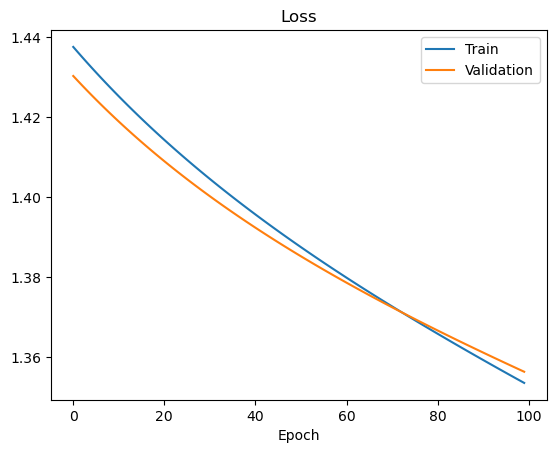

In [1234]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.3229166567325592
Validation accuracy final: 0.3020833432674408


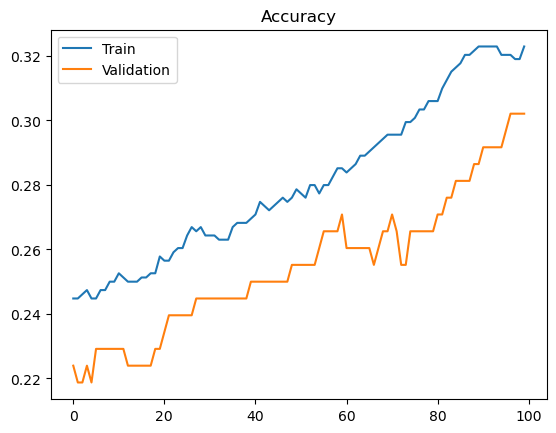

In [1235]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1236]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.25


### Experiment 2

1) Medium Architecture = [50, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0
5) L2 regularization = 0

In [1237]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

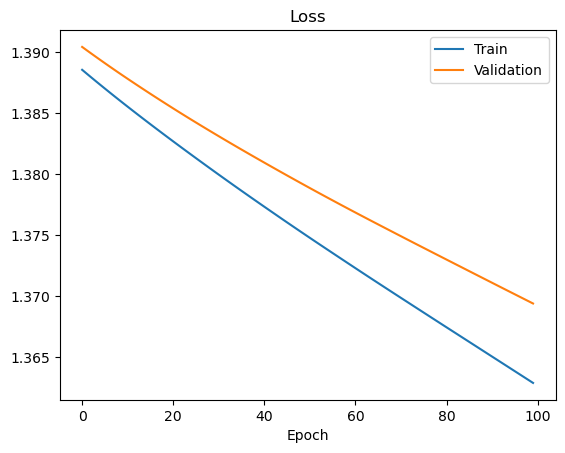

In [1238]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.3307291567325592
Validation accuracy final: 0.3177083432674408


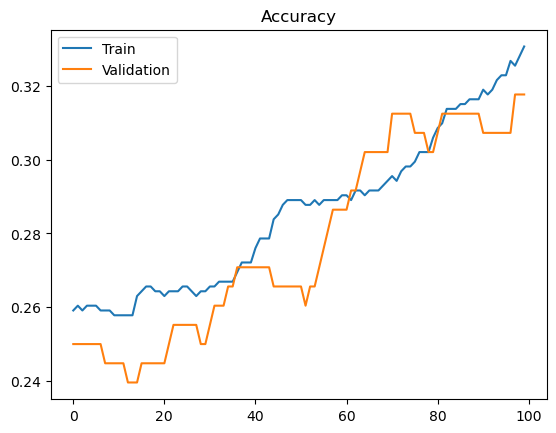

In [1239]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1240]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.3291666805744171


### Experiment 3

1) Deep Architecture = [50, 256, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0
5) L2 regularization = 0

In [1241]:
layers = [50, 256, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

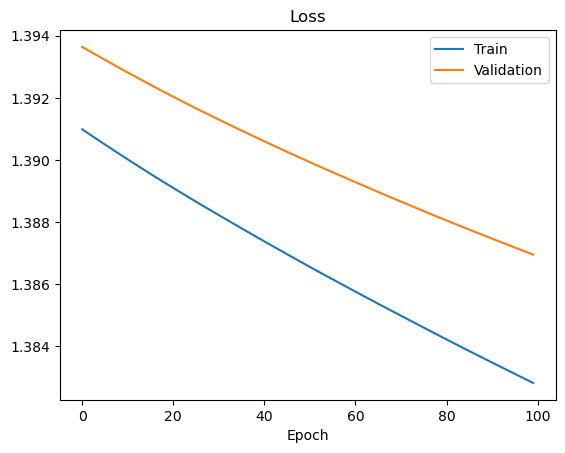

In [1242]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.2955729067325592
Validation accuracy final: 0.2760416567325592


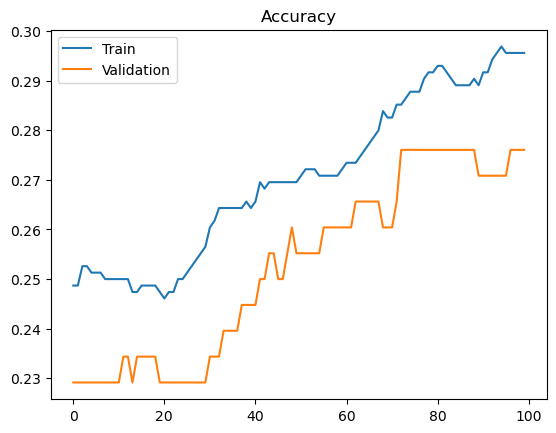

In [1243]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1244]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.27916666865348816


### Experiment 4

1) Small Architecture = [50, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0.1
5) L2 regularization = 0

In [1245]:
layers = [50, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

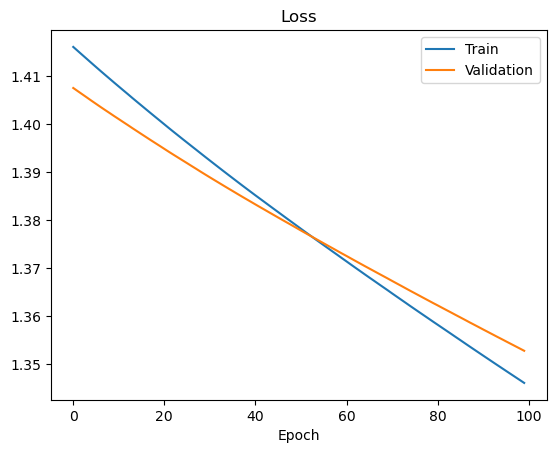

In [1246]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.3424479067325592
Validation accuracy final: 0.3333333432674408


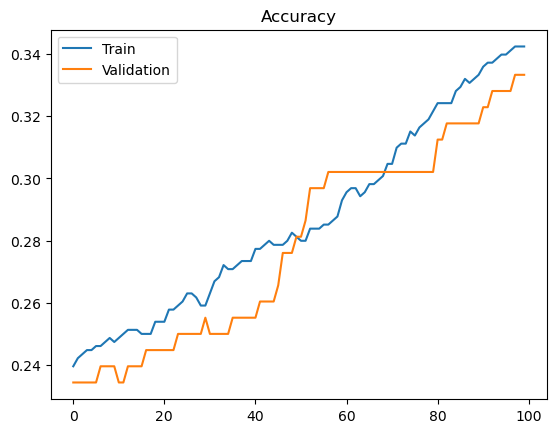

In [1247]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1248]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.4124999940395355


### Experiment 5

1) Medium Architecture = [50, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0.1
5) L2 regularization = 0

In [1249]:
layers = [50, 256, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

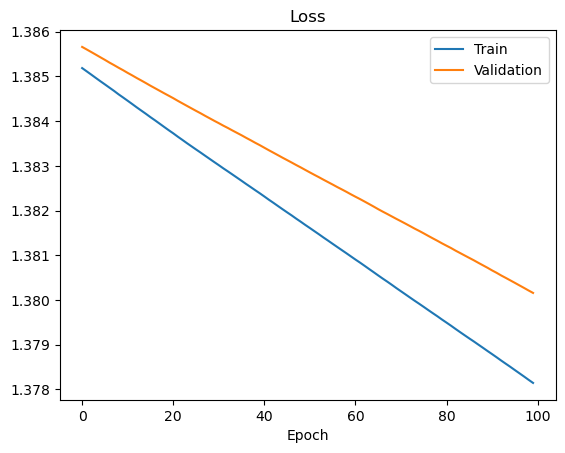

In [1250]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.359375
Validation accuracy final: 0.3333333432674408


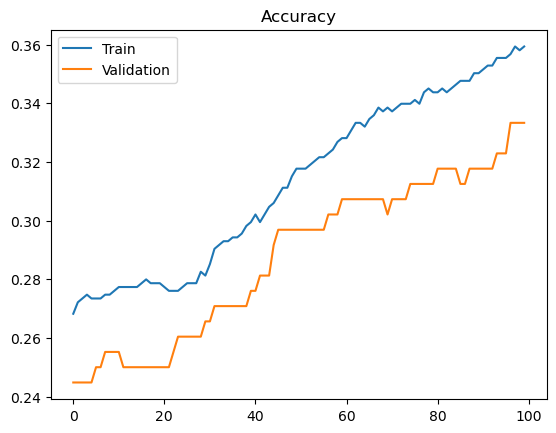

In [1251]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1252]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.2916666567325592


### Experiment 6

1) Deep Architecture = [50, 256, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0.1
5) L2 regularization = 0

In [1253]:
layers = [50, 256, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

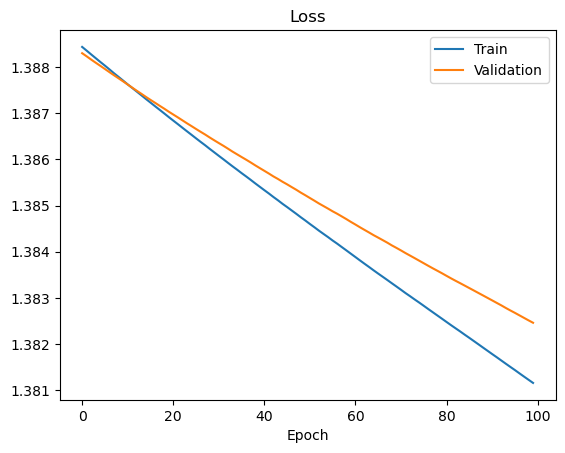

In [1254]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.27734375
Validation accuracy final: 0.28125


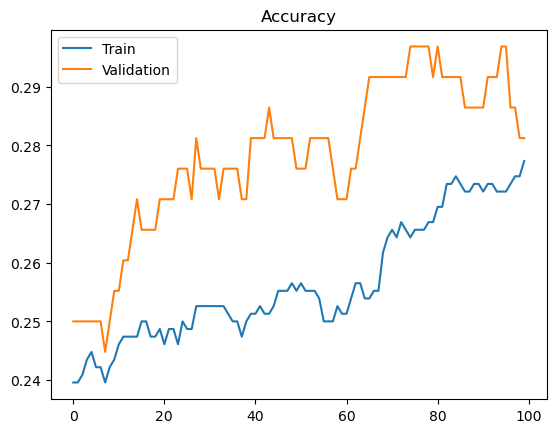

In [1255]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1256]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.26249998807907104


### Experiment 7

1) Small Architecture = [50, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0
5) L2 regularization = 0.001

In [1257]:
layers = [50, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

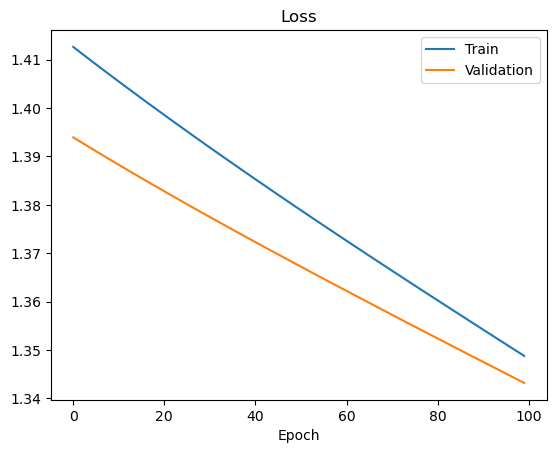

In [1258]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.34375
Validation accuracy final: 0.390625


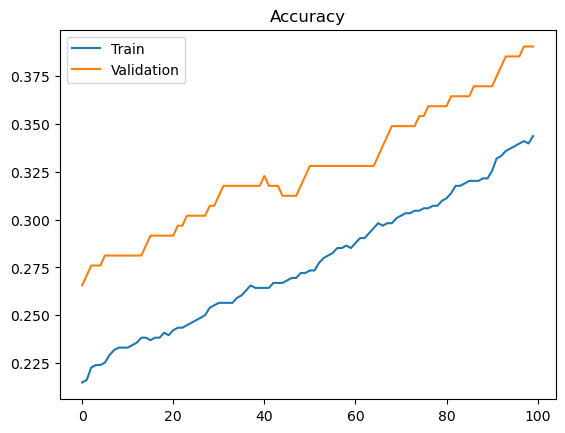

In [1259]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1260]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.3916666805744171


### Experiment 8

1) Medium Architecture = [50, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0
5) L2 regularization = 0.001

In [1261]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

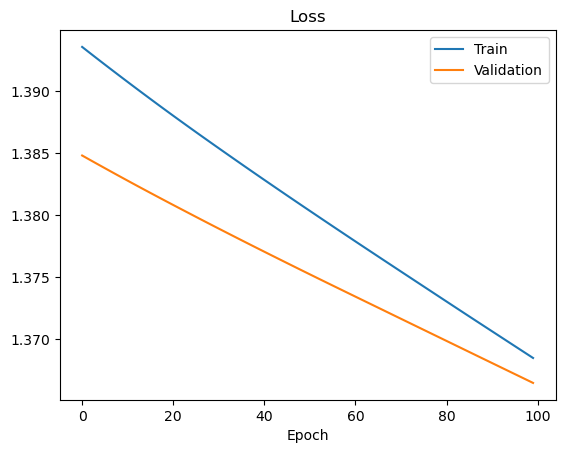

In [1262]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.33203125
Validation accuracy final: 0.3177083432674408


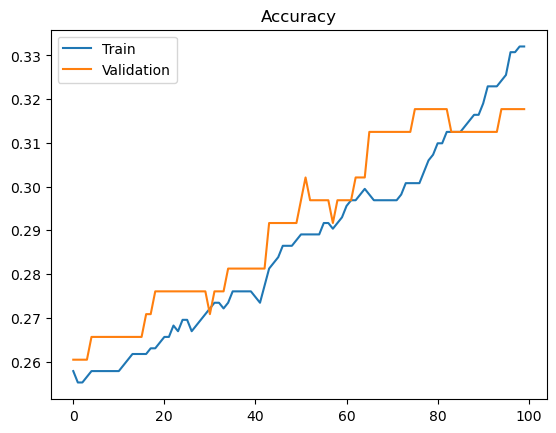

In [1263]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1264]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.26249998807907104


### Experiment 9

1) Deep Architecture = [50, 256, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) ReLU activation function
4) Dropout = 0
5) L2 regularization = 0.001

In [1265]:
layers = [50, 256, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

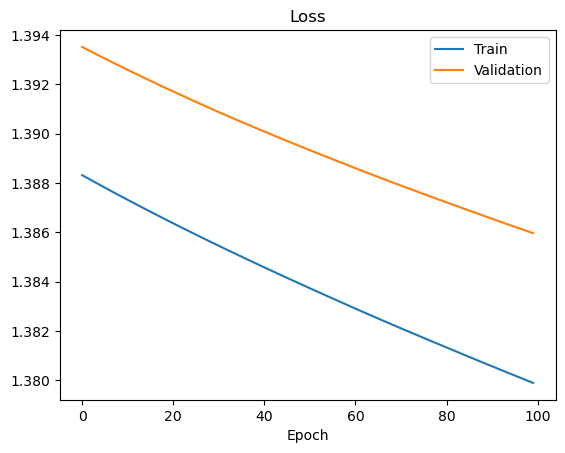

In [1266]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.2747395932674408
Validation accuracy final: 0.2447916716337204


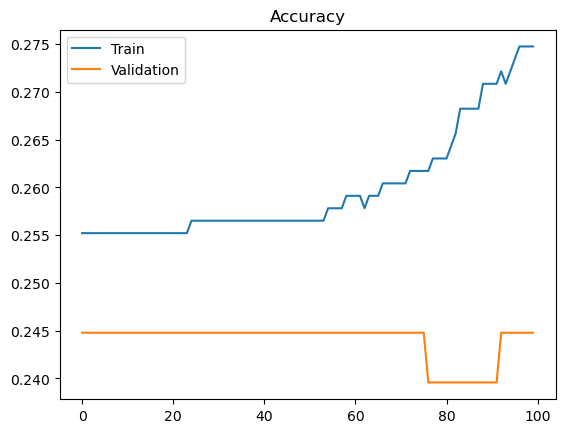

In [1267]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1268]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.25


### Experiment 10

1) Small Architecture = [50, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) Tanh activation function
4) Dropout = 0.0
5) L2 regularization = 0.0

In [1269]:
layers = [50, 64, 4]

model = MLP(layers=layers, activation='tanh', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

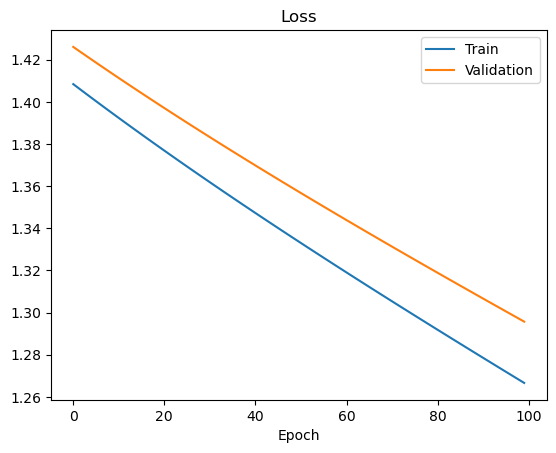

In [1270]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.4674479067325592
Validation accuracy final: 0.4322916567325592


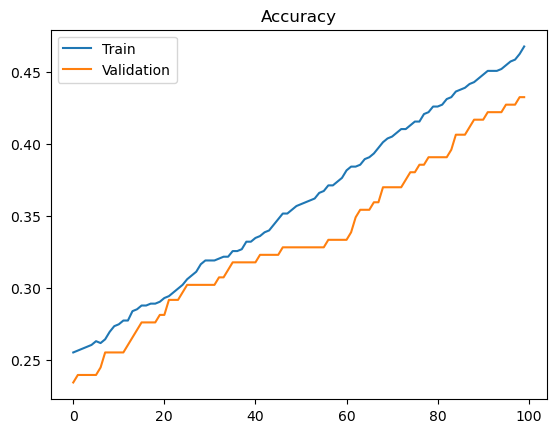

In [1271]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1272]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.4333333373069763


### Experiment 11

1) Medium Architecture = [50, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) Tanh activation function
4) Dropout = 0.0
5) L2 regularization = 0.0

In [1273]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='tanh', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

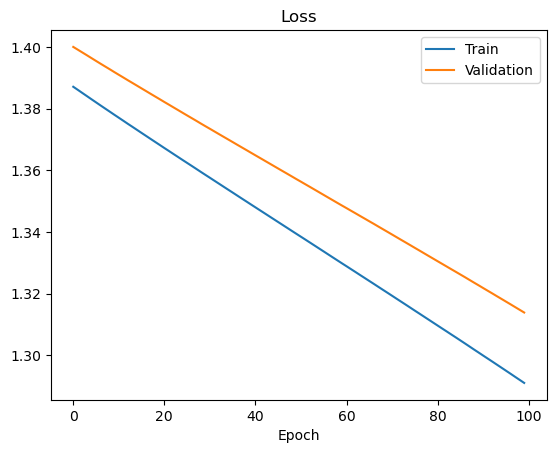

In [1274]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.4700520932674408
Validation accuracy final: 0.4010416567325592


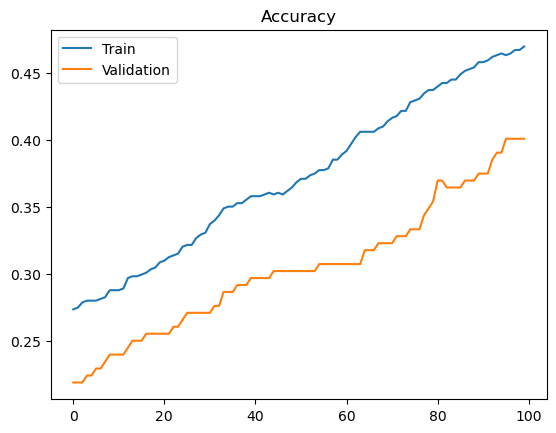

In [1275]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1276]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.47083333134651184


### Experiment 12

1) Deep Architecture = [50, 256, 128, 64, 4]
2) SGD optimiztion with $\eta = 0.01$
3) Tanh activation function
4) Dropout = 0.0
5) L2 regularization = 0.0

In [1277]:
layers = [50, 256, 128, 64, 4]

model = MLP(layers=layers, activation='tanh', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='sgd', lr=0.01, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

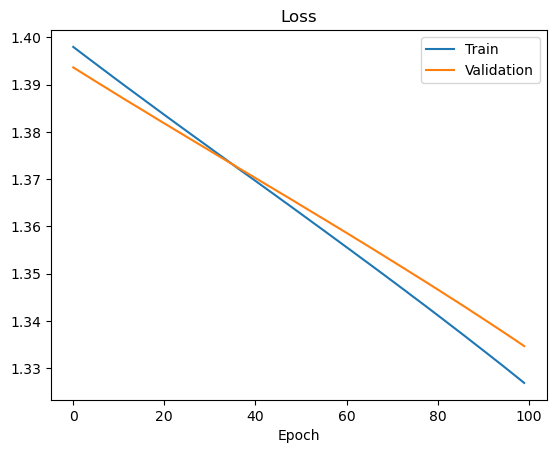

In [1278]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.484375
Validation accuracy final: 0.4479166567325592


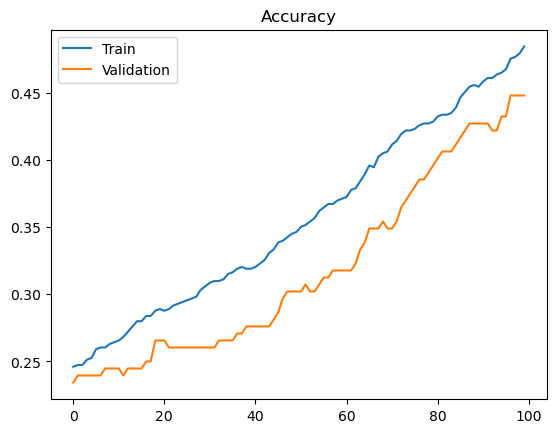

In [1279]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1280]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.4625000059604645


### Experiment 13

1) Small Architecture = [50, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) ReLU activation function
4) Dropout = 0.0
5) L2 regularization = 0.0

In [1281]:
layers = [50, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.001, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

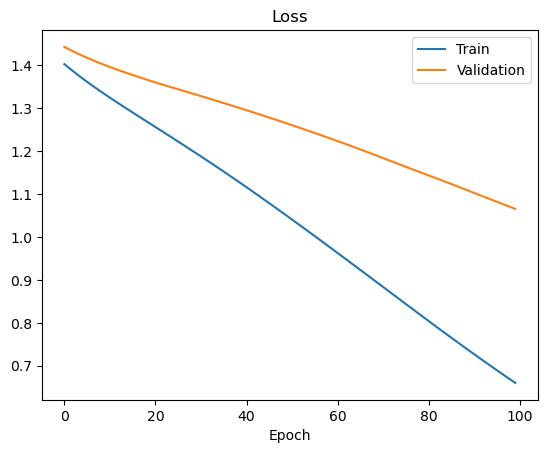

In [1282]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.87890625
Validation accuracy final: 0.5364583134651184


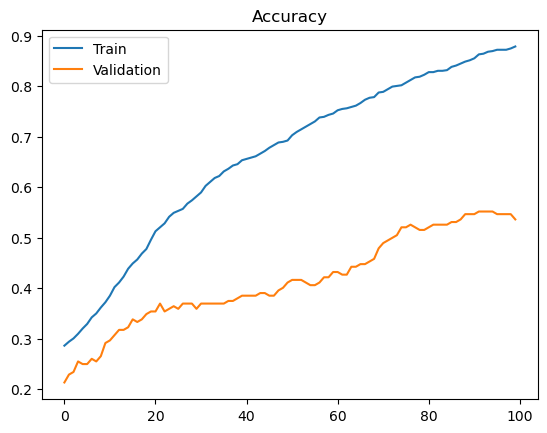

In [1283]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1284]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.5958333611488342


### Experiment 14

1) Medium Architecture = [50, 128, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) ReLU activation function
4) Dropout = 0.0
5) L2 regularization = 0.0

In [1285]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.001, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

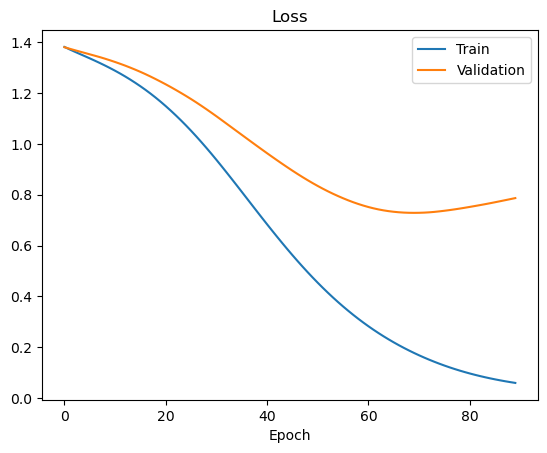

In [1286]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 1.0
Validation accuracy final: 0.7083333134651184


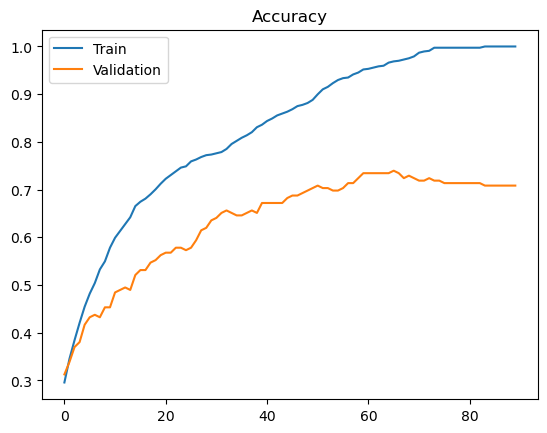

In [1287]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1288]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.7541666626930237


### Experiment 15

1) Deep Architecture = [50, 256, 128, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) ReLU activation function
4) Dropout = 0.0
5) L2 regularization = 0.0

In [1289]:
layers = [50, 256, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.001, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

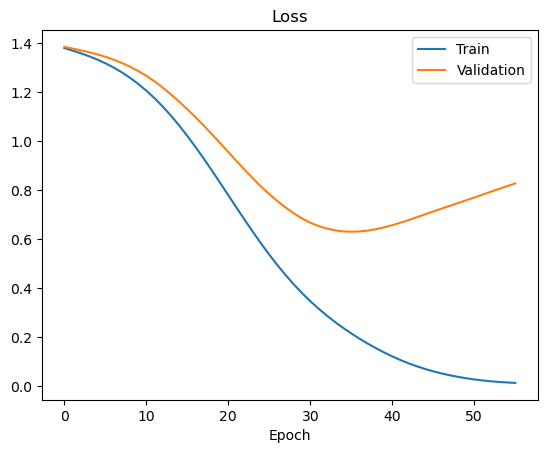

In [1290]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 1.0
Validation accuracy final: 0.75


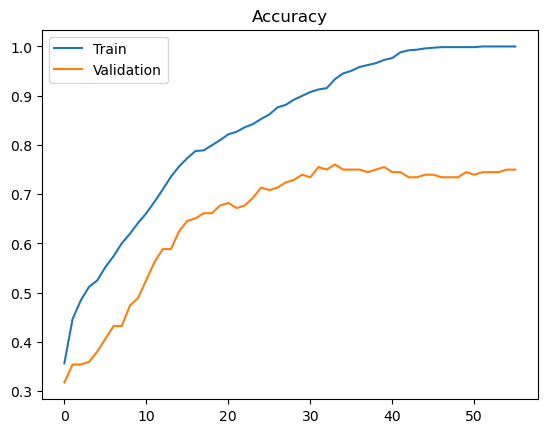

In [1291]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1292]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.7458333373069763


### Experiment 16

1) Deep Architecture = [50, 128, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) ReLU activation function
4) Dropout = 0.1
5) L2 regularization = 0.0

In [1293]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.001, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

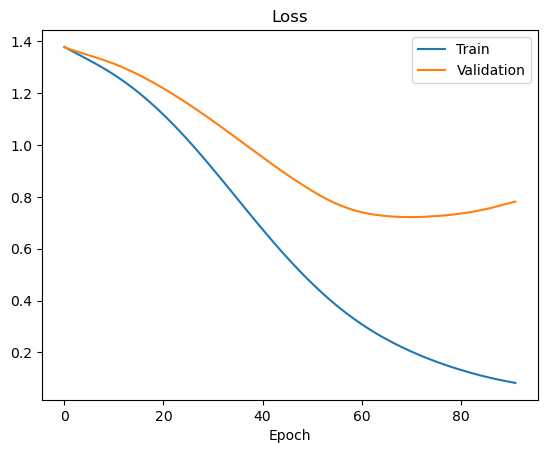

In [1294]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.99609375
Validation accuracy final: 0.7135416865348816


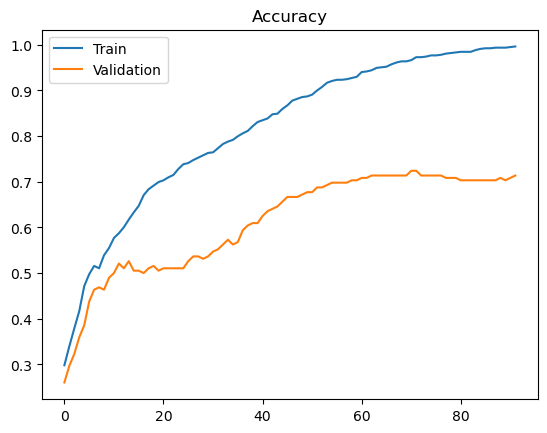

In [1295]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1296]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.7291666865348816


### Experiment 17

1) Deep Architecture = [50, 128, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) Tanh activation function
4) Dropout = 0.1
5) L2 regularization = 0.0

In [1297]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='tanh', dropout=0.1)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.001, l2_lambda=0.0)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

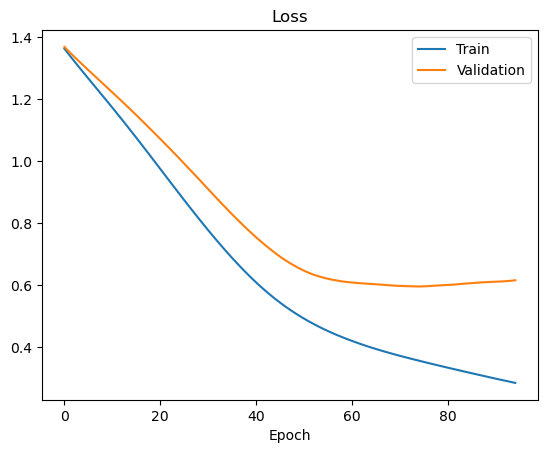

In [1298]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9049479365348816
Validation accuracy final: 0.7708333134651184


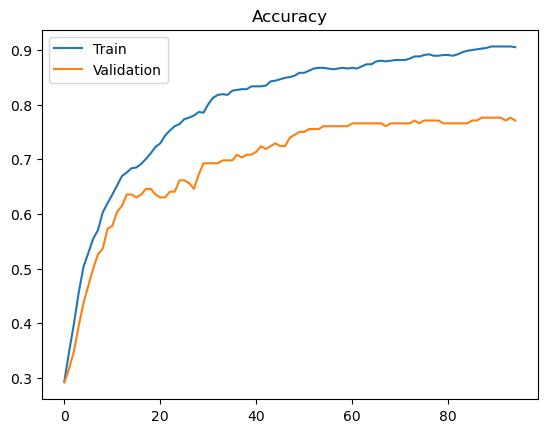

In [1299]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1300]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.7833333611488342


### Experiment 18

1) Medium Architecture = [50, 128, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) Tanh activation function
4) Dropout = 0.0
5) L2 regularization = 0.001

In [1301]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='tanh', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.001, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

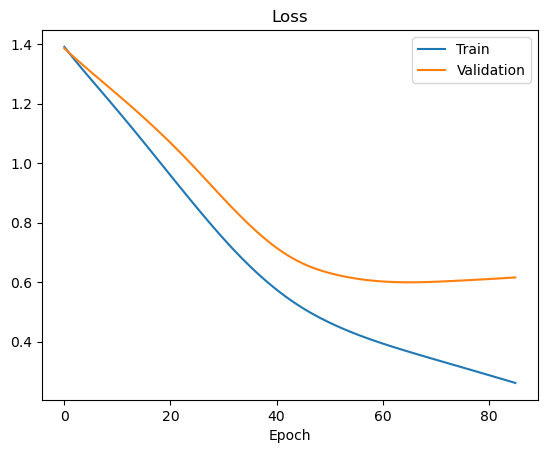

In [1302]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9322916865348816
Validation accuracy final: 0.7604166865348816


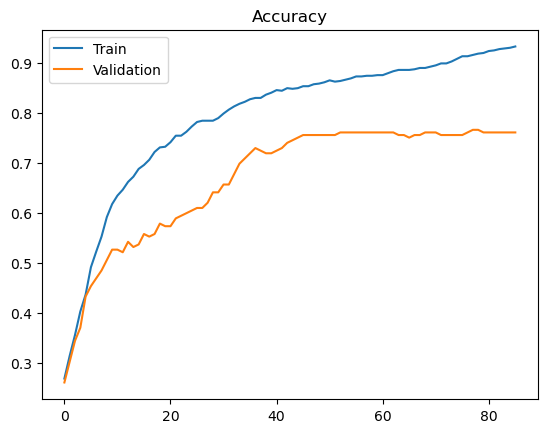

In [1303]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1304]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.7875000238418579


### Experiment 19

1) Deep Architecture = [50, 256, 128, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) Tanh activation function
4) Dropout = 0.0
5) L2 regularization = 0.001

In [1313]:
layers = [50, 256, 128, 64, 4]

model = MLP(layers=layers, activation='tanh', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.01, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

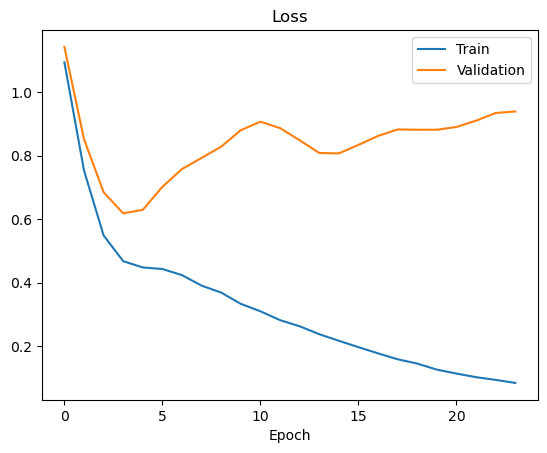

In [1314]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.984375
Validation accuracy final: 0.765625


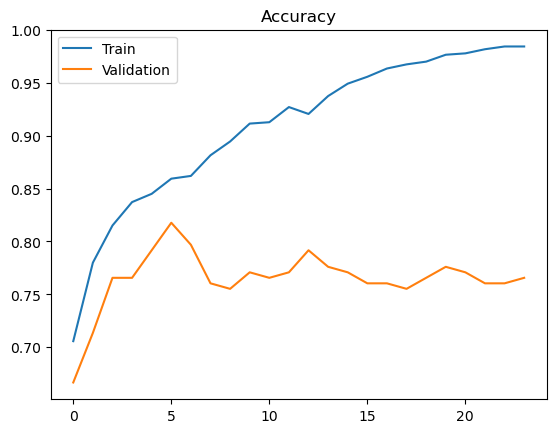

In [1315]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1316]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.7708333134651184


### Experiment 20

1) Deep Architecture = [50, 128, 64, 4]
2) Adam optimiztion with $\eta = 0.001$
3) ReLU activation function
4) Dropout = 0.0
5) L2 regularization = 0.001

In [1317]:
layers = [50, 128, 64, 4]

model = MLP(layers=layers, activation='relu', dropout=0.0)

criterion = get_loss(num_classes)

optimizer = get_optimizer(model, optimizer_name='adam', lr=0.001, l2_lambda=0.001)

train_losses, val_losses, train_accs, val_accs = train(
    model=model,
    X_train=X_train3,
    y_train=y_train3,
    X_val=X_val3,
    y_val=y_val3,
    epochs=100,
    optimizer=optimizer,
    criterion=criterion,
    num_classes=num_classes,
    patience=20
    )

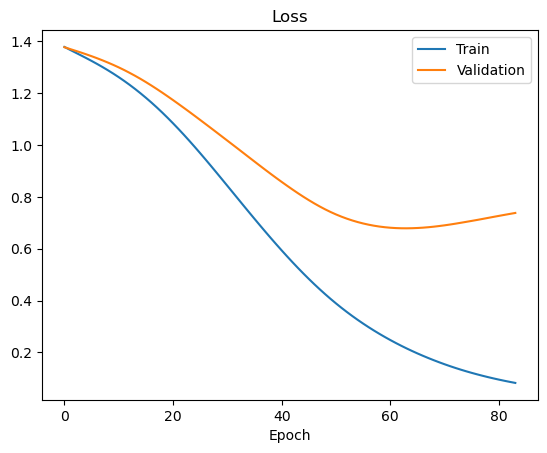

In [1318]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Validation')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.show()

Train accuracy final: 0.9986979365348816
Validation accuracy final: 0.7291666865348816


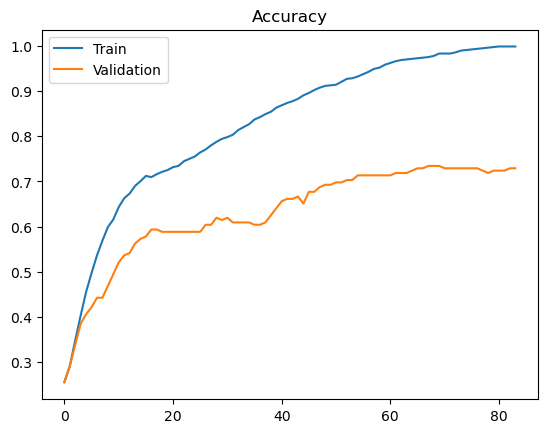

In [1319]:
print("Train accuracy final:", train_accs[-1])
print("Validation accuracy final:", val_accs[-1])

plt.plot(train_accs, label='Train')
plt.plot(val_accs, label='Validation')
plt.legend()
plt.title('Accuracy')
plt.show()

In [1320]:
print("Test accuracy:", evaluate(model, X_test3, y_test3, num_classes))

Test accuracy: 0.762499988079071


# Conclusions about Dataset 3

## General Characteristics

- 50 input features
- 4 output classes
- Larger sample size
- Multiclass classification problem

The complexity of this dataset suggests better optimization methods and stronger control of overfitting.

---

## 1. SGD Experiments (1–12)

The first experiments using SGD produced weak results, with validation accuracy mostly between 24% and 45%, approximately.

Considering a 4-class classification problem, random guessing would produce approximately 25% accuracy. Thus, many SGD configurations only slightly improved over the random baseline.

This suggests that SGD, with fixed learning rate and number of epochs, was not adequate for this dataset.

---

## 2. Adam Improved Optimization

The introduction of Adam immediately improved performance.

Example:

- Train Accuracy ≈ 87.89%
- Validation Accuracy ≈ 53.65%

This confirms much better optimization and lower training loss. However, the large gap between training and validation accuracy indicates overfitting.

---

## 3. Increasing Depth and Complexity

Experiments with deeper networks achieved:

* Experiment 14:

- Train Accuracy ≈ 100%
- Validation Accuracy ≈ 70.83%

* Experiment 15:

- Train Accuracy ≈ 100%
- Validation Accuracy ≈ 75%

Although training performance became excellent, validation gains were limited. This shows that additional complexity improved memorization more than generalization.

---

## 4. Dropout Reduced Overfitting

With dropout:

- Train Accuracy ≈ 99.61%
- Validation Accuracy ≈ 71.35%

The gap slightly decreased compared to previous experiments, showing that dropout partially controlled overfitting, but suggesting that a higher dropout factor may shown a better control.

---

## 5. Tanh Performed Better than ReLU

One of the most relevant findings was Experiments 17 and 18:

* Experiment 17 - with dropout

- Train Accuracy ≈ 90.45%
- Validation Accuracy ≈ 77.08%

* Experiment 18 - with L2

- Train Accuracy ≈ 93.23%
- Validation Accuracy ≈ 76.04%

This was the best balance among all experiments.

Compared to ReLU-based models, Tanh produced:

- lower training overfitting
- better validation performance
- smaller train-validation gap

Since the data was normalized, Tanh may have benefited from centered inputs.

---

## 6. Excessive Complexity Was Not the Best Strategy

Later experiments achieved very high training accuracy:

- Train Accuracy ≈ 98.44%
- Validation Accuracy ≈ 73–77%

However, as one may observe by the Loss Function minimization, the validation curve starts to show some overfitting under this excessive complexity.

---

## Final Conclusion for Dataset 3

SGD struggled to optimize the model, while Adam substantially improved convergence.

However, optimization alone was not enough, since more complex networks frequently suffered from overfitting. The best results were achieved by combining:

- Adam optimizer
- Medium architecture
- Regularization
- Tanh activation

This indicates that controlling generalization was more important than maximizing model capacity.